# Grid-point regression with ridge + OLS

This notebook fits the per-cell CO$_2$ regression using **ordinary least squares with ridge regularization**.
It is the unweighted version of the ridge+WLS notebook: `growth_err` is **not** used as an observation weight.

The model is fit separately at each grid cell $r$:

$$
\underbrace{\texttt{growth\_rate}(t,r)-\texttt{growth\_rate}_{\mathrm{SPO}}(t)}_{\text{SPO-referenced target}}
=
\beta_0(r)
+\beta_E(r)\,\Delta E(t,r)
+\beta_B(r)\,\Delta B(t,r)
+\varepsilon
$$

Main choices:

1. **OLS target fitting**: all valid years in a cell are treated equally.
2. **Ridge regularization**: large coefficients are discouraged using a penalty on
   $\beta_E$ and $\beta_B$; the intercept is not penalized.
3. **Per-cell lambda selection**: the ridge penalty $\lambda$ is chosen separately for each
   grid cell by leave-one-year-out cross-validation.
4. **Out-of-sample evaluation**: `loo_rmse` and `loo_r2` are calculated from held-out years,
   so they are more honest than in-sample $R^2$.
5. **Spatial block bootstrap**: regional summaries use block resampling to reduce the risk of
   overconfident confidence intervals from spatially correlated cells.

## 1. Install

```bash
pip install xarray netCDF4 numpy pandas matplotlib
```

Optional maps: `pip install cartopy`. Optional country masks: `pip install regionmask`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 2. Configuration

In [ ]:
INPUT_FILE = Path("../Input/unified_annual_carbon_dataset_2015_2024.nc")
OUTPUT_DIR = Path("../Output")
FIGURE_DIR = Path("../Figures_and_maps")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_NC  = OUTPUT_DIR / "gridpoint_regression_ridge_ols.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_ridge_ols_flat.csv"

TARGET_VAR   = "growth_rate"
EMISSION_VAR = "delta_emission"
BIO_VAR      = "delta_gosif"

SPO_LAT_MAX = -85.0          # South Pole reference: zonal mean over lat <= this
MIN_OBS     = 6              # need > 3 params; require >= 6 valid years

# Ridge penalties tried per cell.
# 0.0 allows a grid cell to fall back to ordinary unregularized OLS.
LAMBDAS = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0])

print("Input:", INPUT_FILE.resolve())

Input: /content/unified_annual_carbon_dataset_2015_2024.nc


## 3. Open the dataset

In [3]:
ds = xr.open_dataset(INPUT_FILE)
for v in ds.data_vars:
    print(f"- {v}: {ds[v].dims} {ds[v].shape}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/unified_annual_carbon_dataset_2015_2024.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## 4. Target and predictors

The South Pole reference is one value per year, calculated as the zonal mean of
`growth_rate` over the southernmost rows.

The response variable is:

$$
y(t,r) = \texttt{growth\_rate}(t,r)-\texttt{growth\_rate}_{\mathrm{SPO}}(t)
$$

This keeps the regression focused on local/regional deviations from the global background
CO$_2$ growth signal.

Unlike the ridge+WLS notebook, this version does **not** use `growth_err` as a weight.
Every valid year in a grid cell receives equal weight.

In [ ]:
gr = ds[TARGET_VAR].transpose("time", "lat", "lon")
dE = ds[EMISSION_VAR].transpose("time", "lat", "lon")
dB = ds[BIO_VAR].transpose("time", "lat", "lon")

spo = gr.sel(lat=slice(-90, SPO_LAT_MAX)).mean(["lat", "lon"])  # (time,)
y = gr - spo                                                    # SPO-referenced target

print("SPO reference growth rate (ppm/yr):", np.round(spo.values, 3))
print(
    "finite: target", float(np.isfinite(y).mean()),
    "| dE", float(np.isfinite(dE).mean()),
    "| dB", float(np.isfinite(dB).mean())
)

SPO reference growth rate (ppm/yr): [2.09  2.853 2.08  2.442 2.372 2.477 2.152 2.339 2.088 3.096]
finite: target 1.0 | dE 0.8182391975308642 | dB 0.2754861111111111


## 5. Ridge + OLS with closed-form leave-one-year-out

At each cell we solve unweighted ridge regression:

$$
\hat\beta = (X^\top X+\lambda D)^{-1}X^\top y
$$

where:

$$
D = \mathrm{diag}(0,1,1)
$$

So the intercept is not penalized, but the two predictor coefficients are penalized.

The predictors are standardized within each grid cell before ridge is applied. This makes the
penalty fair between `delta_emission` and `delta_gosif`. After fitting, coefficients are
converted back to the original raw units.

For each candidate $\lambda$, leave-one-year-out residuals are computed using the linear
smoother shortcut:

$$
r_t^{\mathrm{LOO}}=\frac{y_t-\hat y_t}{1-h_t}
$$

where $h_t$ is the leverage for year $t$. The selected $\lambda$ is the one with the lowest
leave-one-year-out RMSE for that grid cell.

In [ ]:
def fit_ridge_ols(Yf, X1, X2, valid, lambdas, min_obs):
    """Vectorized ridge+OLS per cell with closed-form leave-one-year-out lambda selection.

    Inputs
    ------
    Yf, X1, X2 : arrays with shape (time, ncell)
        Target and two predictors flattened over the lat-lon grid.
    valid : bool array with shape (time, ncell)
        True where target and predictors are all finite.
    lambdas : array-like
        Ridge penalties to try. lambda=0 is ordinary OLS.
    min_obs : int
        Minimum valid years required for a cell to be fitted.

    Returns
    -------
    dict of arrays with shape (ncell,)
        beta0, betaE, betaB, selected lambda, in-sample metrics, LOO metrics, n_obs.
    """
    T, ncell = Yf.shape
    nval = valid.sum(0)

    out = {
        k: np.full(ncell, np.nan)
        for k in ["beta0", "betaE", "betaB", "lam", "loo_rmse", "loo_r2", "r2", "rmse"]
    }
    out["n_obs"] = nval.astype("int16")

    idx = np.where(nval >= min_obs)[0]
    if idx.size == 0:
        return out

    Y = np.where(valid, Yf, 0.0)[:, idx]     # (T, m)
    a1 = X1[:, idx]
    a2 = X2[:, idx]
    V = valid[:, idx]
    nv = V.sum(0)
    m = idx.size

    # Standardize predictors per cell over valid years.
    # This is necessary so the ridge penalty treats both predictors fairly.
    def stats(a):
        mu = np.where(V, a, 0.0).sum(0) / np.maximum(nv, 1)
        var = np.where(V, (a - mu) ** 2, 0.0).sum(0) / np.maximum(nv, 1)
        return mu, np.sqrt(var)

    mu1, sd1 = stats(a1)
    mu2, sd2 = stats(a2)

    Z1 = np.where(sd1 > 0, (a1 - mu1) / np.where(sd1 > 0, sd1, 1.0), 0.0)
    Z2 = np.where(sd2 > 0, (a2 - mu2) / np.where(sd2 > 0, sd2, 1.0), 0.0)
    Z1 = np.where(V, Z1, 0.0)
    Z2 = np.where(V, Z2, 0.0)

    ones = np.where(V, 1.0, 0.0)
    X = np.stack([ones, Z1, Z2], axis=2)     # (T, m, 3)

    # Unweighted OLS/ridge cross-products.
    XtX = np.einsum("tni,tnj->nij", X, X)   # (m, 3, 3)
    XtY = np.einsum("tni,tn->ni", X, Y)     # (m, 3)

    D = np.diag([0.0, 1.0, 1.0])            # no penalty on intercept
    jitter = 1e-10 * np.eye(3)              # numerical safety

    ybar = np.where(V, Y, 0.0).sum(0) / np.maximum(nv, 1)
    ss_tot = np.where(V, (Y - ybar) ** 2, 0.0).sum(0)

    best_crit = np.full(m, np.inf)
    best = {
        k: np.full(m, np.nan)
        for k in ["a0", "a1", "a2", "lam", "loo_rmse", "loo_r2", "r2", "rmse"]
    }

    for lam in lambdas:
        M = XtX + lam * D + jitter
        Minv = np.linalg.inv(M)                         # (m, 3, 3)
        beta = np.einsum("nij,nj->ni", Minv, XtY)       # (m, 3)

        yhat = np.einsum("tni,ni->tn", X, beta)         # (T, m)
        h = np.einsum("tni,nij,tnj->tn", X, Minv, X)    # leverage

        denom = 1.0 - h
        good = V & (denom > 1e-6)

        loo_resid = np.where(good, (Y - yhat) / np.where(good, denom, 1.0), 0.0)

        ng = good.sum(0)
        loo_mse = np.where(good, loo_resid ** 2, 0.0).sum(0) / np.maximum(ng, 1)
        loo_rmse = np.sqrt(loo_mse)
        loo_ss = np.where(good, loo_resid ** 2, 0.0).sum(0)
        loo_r2 = 1.0 - loo_ss / np.where(ss_tot > 0, ss_tot, np.nan)

        resid = np.where(V, Y - yhat, 0.0)
        ss_res = (resid ** 2).sum(0)
        r2 = 1.0 - ss_res / np.where(ss_tot > 0, ss_tot, np.nan)
        rmse = np.sqrt(ss_res / np.maximum(nv, 1))

        imp = loo_mse < best_crit
        best_crit = np.where(imp, loo_mse, best_crit)

        best["a0"] = np.where(imp, beta[:, 0], best["a0"])
        best["a1"] = np.where(imp, beta[:, 1], best["a1"])
        best["a2"] = np.where(imp, beta[:, 2], best["a2"])
        best["lam"] = np.where(imp, lam, best["lam"])
        best["loo_rmse"] = np.where(imp, loo_rmse, best["loo_rmse"])
        best["loo_r2"] = np.where(imp, loo_r2, best["loo_r2"])
        best["r2"] = np.where(imp, r2, best["r2"])
        best["rmse"] = np.where(imp, rmse, best["rmse"])

    # Back-transform standardized coefficients to raw predictor units.
    bE = np.where(sd1 > 0, best["a1"] / np.where(sd1 > 0, sd1, 1.0), 0.0)
    bB = np.where(sd2 > 0, best["a2"] / np.where(sd2 > 0, sd2, 1.0), 0.0)
    b0 = (
        best["a0"]
        - np.where(sd1 > 0, best["a1"] * mu1 / np.where(sd1 > 0, sd1, 1.0), 0.0)
        - np.where(sd2 > 0, best["a2"] * mu2 / np.where(sd2 > 0, sd2, 1.0), 0.0)
    )

    for k, v in zip(
        ["beta0", "betaE", "betaB", "lam", "loo_rmse", "loo_r2", "r2", "rmse"],
        [b0, bE, bB, best["lam"], best["loo_rmse"], best["loo_r2"], best["r2"], best["rmse"]],
    ):
        out[k][idx] = v

    return out

## 6. Fit ridge + OLS

In [ ]:
nlat, nlon = ds.sizes["lat"], ds.sizes["lon"]
T = ds.sizes["time"]
ncell = nlat * nlon

Yf = y.values.reshape(T, ncell).astype("float64")
X1 = dE.values.reshape(T, ncell).astype("float64")
X2 = dB.values.reshape(T, ncell).astype("float64")

valid = np.isfinite(Yf) & np.isfinite(X1) & np.isfinite(X2)

res = fit_ridge_ols(Yf, X1, X2, valid, LAMBDAS, MIN_OBS)

print("median leave-one-year-out RMSE (ppm/yr), lower = better:")
print(f"  ridge+OLS: {np.nanmedian(res['loo_rmse']):.4f}")

print("\nselected lambda distribution:")
print(pd.Series(res["lam"]).value_counts(dropna=True).sort_index())

median leave-one-year-out RMSE (ppm/yr), lower = better:
  ridge+OLS: 0.3539

selected lambda distribution:
0.00       324
0.03        25
0.10        69
0.30       295
1.00       785
3.00      2022
10.00     2605
30.00    11422
Name: count, dtype: int64


## 7. Assemble and save

In [ ]:
lat = ds["lat"].values
lon = ds["lon"].values

g = lambda a: a.reshape(nlat, nlon)

out = xr.Dataset(
    {
        k: (("lat", "lon"), g(res[k]))
        for k in ["beta0", "betaE", "betaB", "lam", "loo_rmse", "loo_r2", "r2", "rmse"]
    }
    | {"n_obs": (("lat", "lon"), g(res["n_obs"]))},
    coords={"lat": lat, "lon": lon},
    attrs={
        "model": "ridge+OLS, SPO-ref target, delta predictors, per-cell LOOCV lambda",
        "weights": "none; all valid years are equally weighted"
    },
)

out.to_netcdf(OUTPUT_NC, encoding={v: {"zlib": True, "complevel": 4} for v in out.data_vars})
out.to_dataframe().reset_index().to_csv(OUTPUT_CSV, index=False)

print("saved:", OUTPUT_NC.name, "and", OUTPUT_CSV.name)

saved: gridpoint_regression_ridge_ols.nc and gridpoint_regression_ridge_ols_flat.csv


## 8. Map helper

In [ ]:
def plot_map(da, title=None, cmap="coolwarm", robust=True, save=None):
    title = title or da.name

    if HAS_CARTOPY:
        plt.figure(figsize=(13, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        da.plot(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            robust=robust,
            cbar_kwargs={"label": da.name},
        )
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_global()
        ax.set_title(title)
    else:
        plt.figure(figsize=(12, 5))
        da.plot(x="lon", y="lat", cmap=cmap, robust=robust, cbar_kwargs={"label": da.name})
        plt.title(title)
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=110, bbox_inches="tight")
    plt.show()

## 9. Coefficient maps

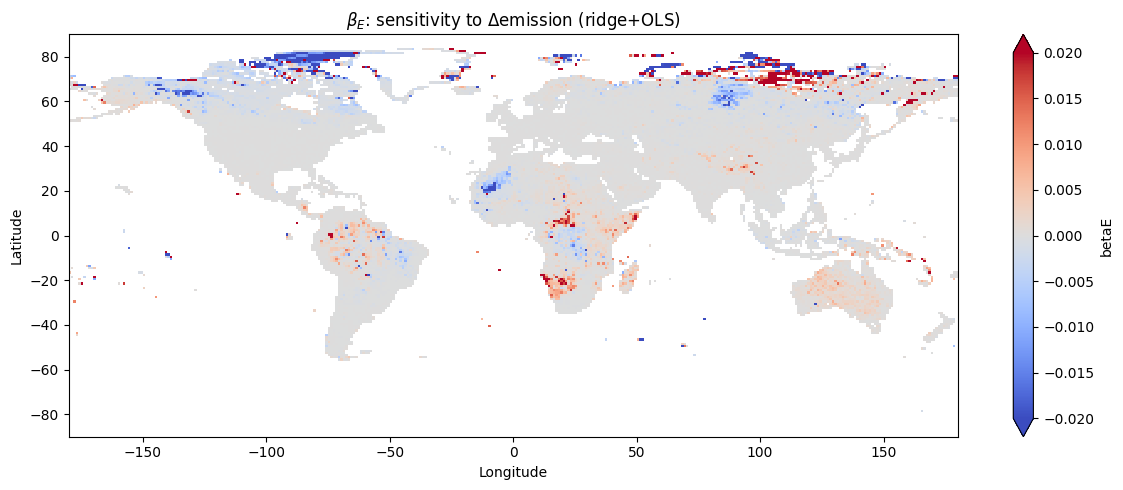

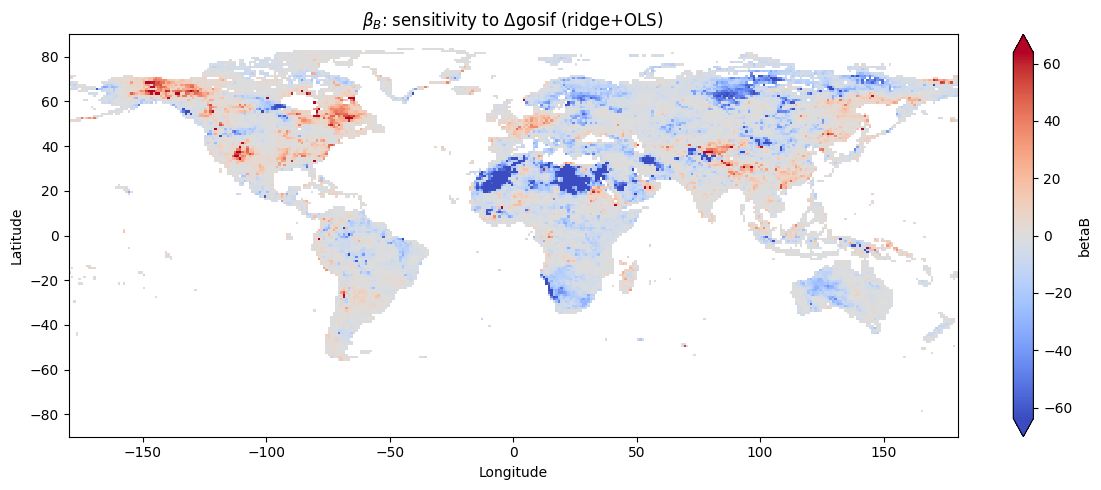

In [ ]:
plot_map(
    out["betaE"],
    title=r"$\beta_E$: sensitivity to $\Delta$emission (ridge+OLS)",
    save=FIGURE_DIR / "betaE_ridge_ols.png",
)

plot_map(
    out["betaB"],
    title=r"$\beta_B$: sensitivity to $\Delta$gosif (ridge+OLS)",
    save=FIGURE_DIR / "betaB_ridge_ols.png",
)

## 10. Leave-one-year-out skill map

This is the map to trust most. `loo_rmse` is the out-of-sample prediction error in ppm/yr.

`loo_r2` is the held-out $R^2$. It becomes negative where the model predicts worse than the
cell mean, which usually means the regression is fitting noise at that grid cell.

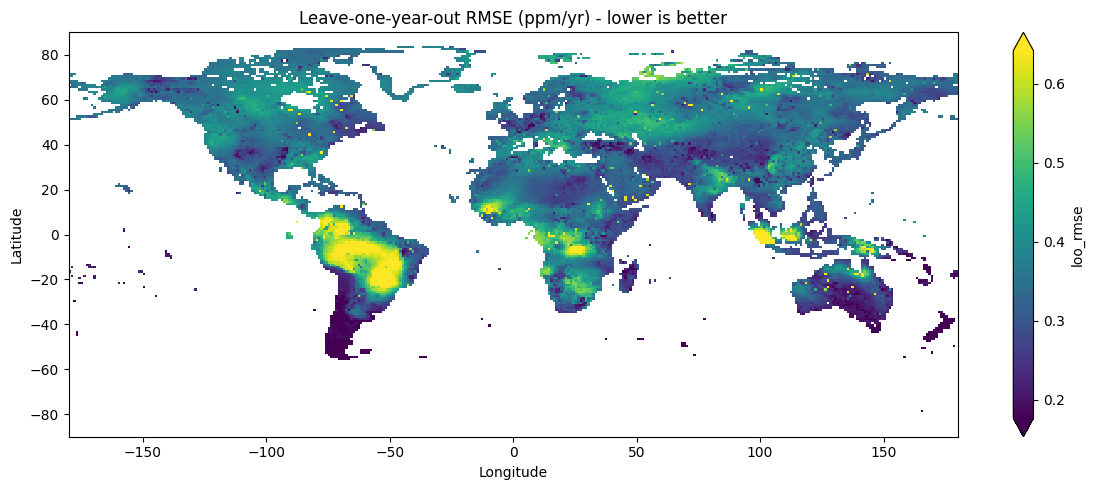

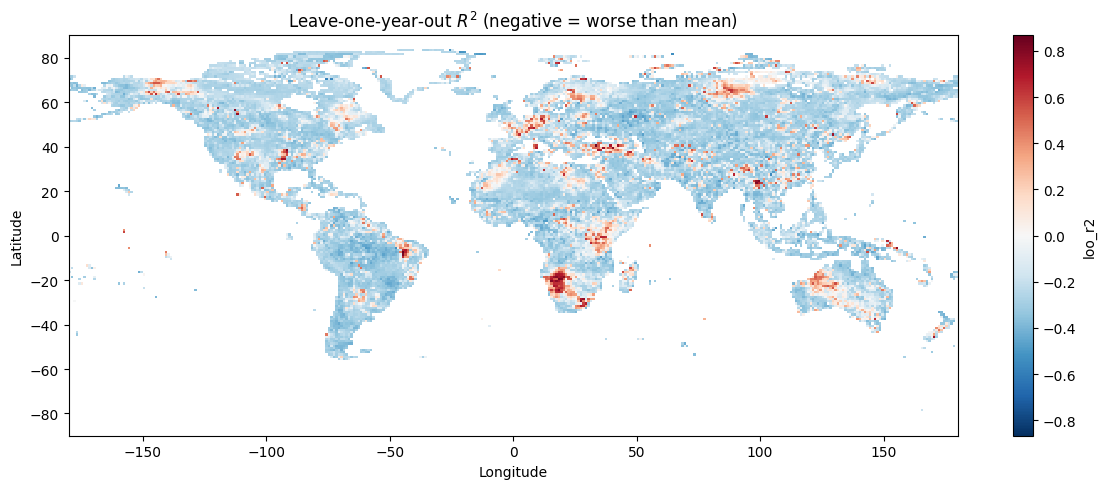

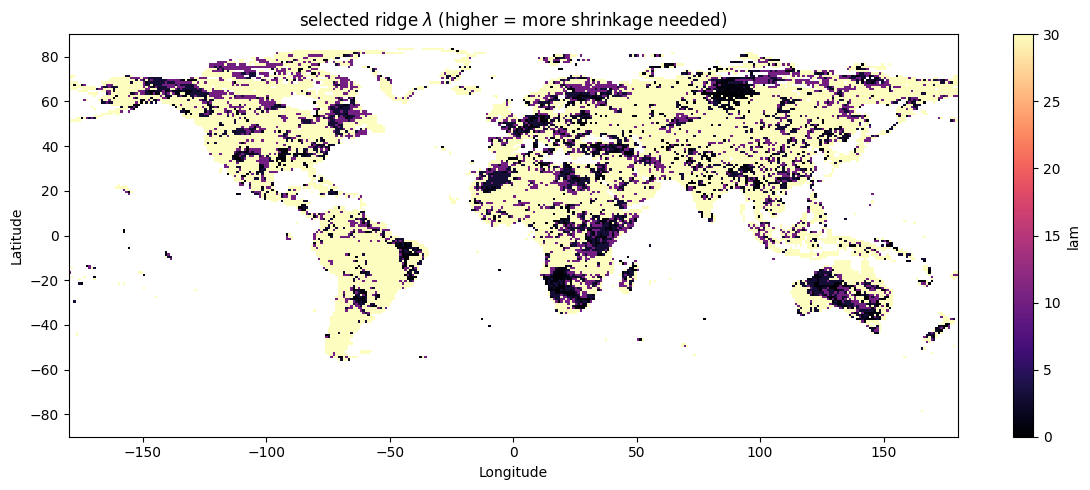

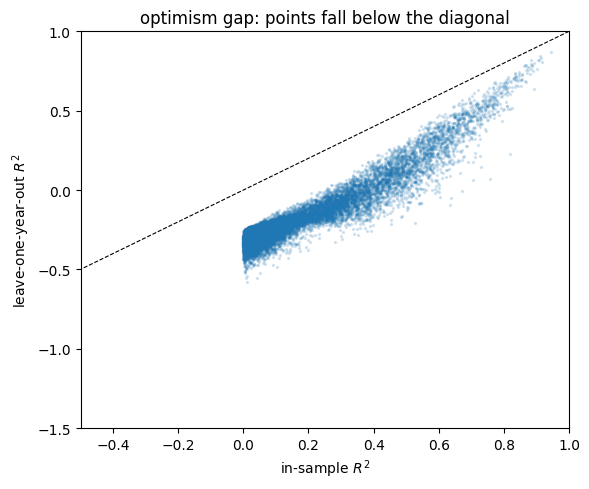

In [ ]:
plot_map(
    out["loo_rmse"],
    title="Leave-one-year-out RMSE (ppm/yr) - lower is better",
    cmap="viridis",
    save=FIGURE_DIR / "loo_rmse_skill_ridge_ols.png",
)

plot_map(
    out["loo_r2"].clip(-1, 1),
    title=r"Leave-one-year-out $R^2$ (negative = worse than mean)",
    cmap="RdBu_r",
    robust=False,
    save=FIGURE_DIR / "loo_r2_skill_ridge_ols.png",
)

plot_map(
    out["lam"],
    title=r"selected ridge $\lambda$ (higher = more shrinkage needed)",
    cmap="magma",
    robust=False,
    save=FIGURE_DIR / "lambda_map_ridge_ols.png",
)

# Optimism: in-sample vs out-of-sample.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(out["r2"].values.ravel(), out["loo_r2"].values.ravel(), s=2, alpha=0.15)
ax.plot([-1, 1], [-1, 1], "k--", lw=0.8)
ax.set_xlim(-0.5, 1)
ax.set_ylim(-1.5, 1)
ax.set_xlabel("in-sample $R^2$")
ax.set_ylabel("leave-one-year-out $R^2$")
ax.set_title("optimism gap: points fall below the diagonal")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "optimism_gap_ridge_ols.png", dpi=110)
plt.show()

auto-selected cell with lowest LOO RMSE
lat = -78.500, lon = 165.500
selected lambda = 30
LOO RMSE = 0.0522 ppm/yr
LOO R² = -0.1963


,time,observed_target,predicted_full_fit,predicted_LOO,delta_emission,delta_gosif
0,2015,-0.016379,0.017720,0.022000,0.807172,0.000000
1,2016,0.081115,0.023077,0.012050,-2.745167,0.000000
2,2017,0.011483,0.012908,0.013326,3.998574,0.000000
3,2018,0.028314,0.035307,0.036953,-3.027489,-0.015592
4,2019,0.060822,0.019286,0.014359,-0.188962,-0.000083
5,2020,-0.044444,0.020764,0.028488,-0.637895,-0.001142
6,2021,-0.012682,0.018209,0.021951,0.240483,0.000483
7,2022,-0.021851,0.018526,0.023390,0.022123,0.000500
8,2023,0.025136,0.019132,0.018420,0.590470,-0.001433
9,2024,0.114711,0.041295,0.013984,-0.161211,-0.029208


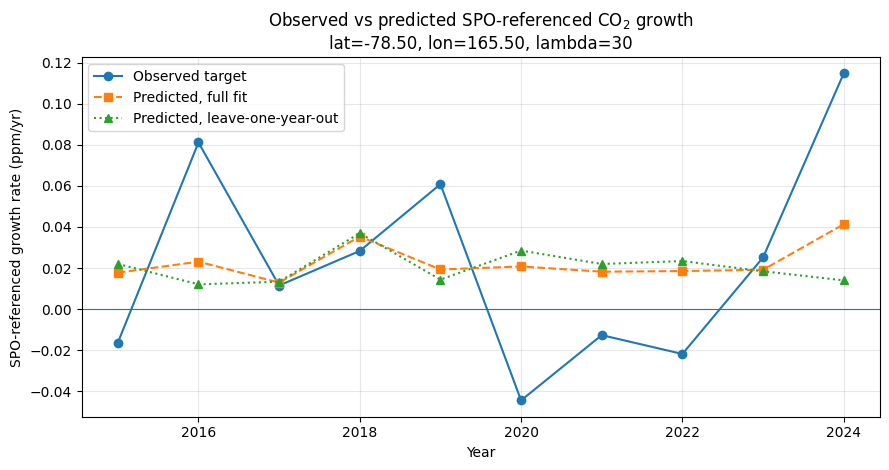

In [ ]:
# Plot observed target vs predicted value for one grid cell
# Leave as None to auto-select the fitted grid cell with the lowest LOO RMSE.
# Or set values, for example:
# PLOT_LAT = 40.0
# PLOT_LON = -100.0

PLOT_LAT = None
PLOT_LON = None


def nearest_valid_grid_cell(out, lat_values, lon_values, target_lat=None, target_lon=None):
    finite_model = np.isfinite(out["beta0"].values) & np.isfinite(out["loo_rmse"].values)

    if not np.any(finite_model):
        raise ValueError("No fitted grid cells available. Run the fitting cells first.")

    if target_lat is None or target_lon is None:
        score = out["loo_rmse"].values
        masked_score = np.where(finite_model, score, np.nan)
        ilat, ilon = np.unravel_index(np.nanargmin(masked_score), masked_score.shape)
        return ilat, ilon, "auto-selected cell with lowest LOO RMSE"

    target_lon = float(target_lon)

    # Convert requested longitude to the same convention as the dataset.
    if np.nanmin(lon_values) >= 0 and target_lon < 0:
        target_lon = target_lon % 360
    elif np.nanmax(lon_values) <= 180 and target_lon > 180:
        target_lon = ((target_lon + 180) % 360) - 180

    LON, LAT = np.meshgrid(lon_values, lat_values)

    dlat = LAT - float(target_lat)
    dlon = np.abs(LON - target_lon)
    dlon = np.minimum(dlon, 360.0 - dlon)

    dist2 = dlat**2 + dlon**2
    dist2 = np.where(finite_model, dist2, np.inf)

    ilat, ilon = np.unravel_index(np.argmin(dist2), dist2.shape)
    return ilat, ilon, "nearest fitted cell to requested location"


def ridge_ols_predictions_one_cell(target, x1, x2, lam, min_obs):
    """
    Returns:
    - full_pred: prediction from the model fit using all valid years
    - loo_pred: leave-one-year-out prediction for each year
    """
    target = np.asarray(target, dtype="float64")
    x1 = np.asarray(x1, dtype="float64")
    x2 = np.asarray(x2, dtype="float64")

    valid_ts = np.isfinite(target) & np.isfinite(x1) & np.isfinite(x2)

    full_pred = np.full_like(target, np.nan, dtype="float64")
    loo_pred = np.full_like(target, np.nan, dtype="float64")

    if valid_ts.sum() < min_obs:
        return full_pred, loo_pred

    yy = target[valid_ts]
    xx1 = x1[valid_ts]
    xx2 = x2[valid_ts]

    # Same standardization logic as in the ridge fitting cell
    mu1, sd1 = xx1.mean(), xx1.std()
    mu2, sd2 = xx2.mean(), xx2.std()

    z1 = (xx1 - mu1) / sd1 if sd1 > 0 else np.zeros_like(xx1)
    z2 = (xx2 - mu2) / sd2 if sd2 > 0 else np.zeros_like(xx2)

    X = np.column_stack([np.ones_like(yy), z1, z2])

    # Ridge penalty: intercept is not penalized
    D = np.diag([0.0, 1.0, 1.0])
    jitter = 1e-10 * np.eye(3)

    M = X.T @ X + float(lam) * D + jitter
    Minv = np.linalg.inv(M)
    beta = Minv @ X.T @ yy

    fitted = X @ beta

    # Closed-form leave-one-year-out prediction
    h = np.einsum("ij,jk,ik->i", X, Minv, X)
    denom = 1.0 - h

    ok = denom > 1e-6
    held_out = np.full_like(yy, np.nan, dtype="float64")
    held_out[ok] = yy[ok] - (yy[ok] - fitted[ok]) / denom[ok]

    full_pred[valid_ts] = fitted
    loo_pred[valid_ts] = held_out

    return full_pred, loo_pred


lat_values = out["lat"].values
lon_values = out["lon"].values

ilat, ilon, selection_label = nearest_valid_grid_cell(
    out,
    lat_values,
    lon_values,
    target_lat=PLOT_LAT,
    target_lon=PLOT_LON,
)

sel_lat = float(lat_values[ilat])
sel_lon = float(lon_values[ilon])

obs = y.isel(lat=ilat, lon=ilon).values
x_emis = dE.isel(lat=ilat, lon=ilon).values
x_bio = dB.isel(lat=ilat, lon=ilon).values

lam = float(out["lam"].isel(lat=ilat, lon=ilon))

pred_full, pred_loo = ridge_ols_predictions_one_cell(
    obs,
    x_emis,
    x_bio,
    lam,
    MIN_OBS,
)

time_values = ds["time"].values

ts_df = pd.DataFrame(
    {
        "time": time_values,
        "observed_target": obs,
        "predicted_full_fit": pred_full,
        "predicted_LOO": pred_loo,
        "delta_emission": x_emis,
        "delta_gosif": x_bio,
    }
)

print(selection_label)
print(f"lat = {sel_lat:.3f}, lon = {sel_lon:.3f}")
print(f"selected lambda = {lam:g}")
print(f"LOO RMSE = {float(out['loo_rmse'].isel(lat=ilat, lon=ilon)):.4f} ppm/yr")
print(f"LOO R² = {float(out['loo_r2'].isel(lat=ilat, lon=ilon)):.4f}")

display(ts_df)

plt.figure(figsize=(9, 4.8))

plt.plot(
    time_values,
    obs,
    marker="o",
    label="Observed target",
)

plt.plot(
    time_values,
    pred_full,
    marker="s",
    linestyle="--",
    label="Predicted, full fit",
)

plt.plot(
    time_values,
    pred_loo,
    marker="^",
    linestyle=":",
    label="Predicted, leave-one-year-out",
)

plt.axhline(0, linewidth=0.8)

plt.title(
    "Observed vs predicted SPO-referenced CO$_2$ growth\n"
    f"lat={sel_lat:.2f}, lon={sel_lon:.2f}, lambda={lam:g}"
)

plt.xlabel("Year")
plt.ylabel("SPO-referenced growth rate (ppm/yr)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Spatial block bootstrap for regional aggregates

Neighbouring cells are correlated because of atmospheric transport, so treating every grid
cell as independent gives confidence intervals that are too tight.

The block bootstrap below resamples coarse spatial tiles with replacement and recomputes
the regional mean. The bounding boxes are intentionally simple; replace them with
`regionmask` country masks before using the numbers in a paper.

In [ ]:
def block_bootstrap_mean(field, lat, lon, mask, block_deg=10, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)

    LON, LAT = np.meshgrid(lon, lat)
    block = ((LAT + 90) // block_deg).astype(int) * 10000 + ((LON + 180) // block_deg).astype(int)

    sel = mask & np.isfinite(field)
    ids, vals = block[sel], field[sel]

    uniq = np.unique(ids)
    groups = [vals[ids == u] for u in uniq]
    nb = len(uniq)

    if nb < 2:
        return np.nanmean(vals) if vals.size else np.nan, np.nan, np.nan

    boots = np.empty(n_boot)
    for b in range(n_boot):
        pick = rng.integers(0, nb, size=nb)
        boots[b] = np.concatenate([groups[p] for p in pick]).mean()

    return (
        float(np.nanmean(vals)),
        float(np.percentile(boots, 2.5)),
        float(np.percentile(boots, 97.5)),
    )


# Approximate country boxes (lat_min, lat_max, lon_min, lon_max). REPLACE with regionmask:
#   import regionmask
#   countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_50
#   mask3d = countries.mask_3D(lon, lat)   # then pick country indices; EU = union of members
BOXES = {
    "EU (box)":    (35,  70, -10,   30),
    "USA (box)":   (25,  49, -125, -66),
    "China (box)": (18,  53,   73, 135),
    "India (box)": ( 6,  37,   68,  98),
    "Brazil (box)":(-34,  6,  -74, -34),
}

LON, LAT = np.meshgrid(lon, lat)

rows = []
for name, (la0, la1, lo0, lo1) in BOXES.items():
    mask = (LAT >= la0) & (LAT <= la1) & (LON >= lo0) & (LON <= lo1)

    for var in ["betaE", "betaB", "loo_rmse", "loo_r2"]:
        mean, lo, hi = block_bootstrap_mean(out[var].values, lat, lon, mask)
        rows.append(
            {
                "region": name,
                "variable": var,
                "mean": mean,
                "ci_low": lo,
                "ci_high": hi,
                "ci_excludes_zero": bool((lo > 0) or (hi < 0)) if np.isfinite(lo) and np.isfinite(hi) else False,
            }
        )

regional = pd.DataFrame(rows)
regional.to_csv(OUTPUT_DIR / "regional_block_bootstrap_ridge_ols.csv", index=False)
regional

## 12. Interpretation notes

- This notebook is the **ridge+OLS** version: no `growth_err` weights are used.
- Ridge is still useful because each grid cell has few annual observations, so unregularized
  coefficients can be unstable.
- The selected `lam` is chosen independently for each cell by leave-one-year-out RMSE.
- `loo_rmse` is the most important skill map. Low values mean the model predicts held-out
  years better; high values mean the coefficient maps should not be over-interpreted.
- Negative `loo_r2` means the regression predicts worse than simply using the cell mean.
- Regional summaries are more defensible than pixel-by-pixel claims, but country boxes
  should be replaced with proper masks before reporting final numbers.
- Coefficients are statistical associations, not causal flux sensitivities. CO$_2$ is
  transported and mixed, and ten years is short.